# 📘 pCN Chain Diagnostics — Theory & Intuition

This section explains the mathematical ideas behind MCMC diagnostics you will apply to the pCN chain:  
ESS, Trace Plots, Running Means, Autocorrelation, Posterior Mean/Variance, and Truth Comparison.

---

#  1. Effective Sample Size (ESS)

### **Definition**

For a Markov chain $$ u^{(1)}, u^{(2)}, \dots, u^{(M)} $$, samples are correlated.  
The **effective sample size** (ESS) measures how many *independent* samples the chain contains.

For one component $$u_k$$:

$$
\mathrm{ESS}_k = \frac{M}{\tau_k},
$$

where

$$
\tau_k = 1 + 2\sum_{\ell=1}^{\infty} \rho_k(\ell)
$$


---

### **Intuition**

- If mixing is good → autocorrelation is small → ESS ≈ M  
- If mixing is poor → autocorrelation is large → ESS ≪ M  
- ESS tells you **how much real information** your samples contain.

---

### **Rule of thumb**

- **ESS > 500** → excellent  
- **ESS > 100** → good  
- **ESS < 50** → bad  
- **ESS < 10** → unusable  

---

In [1]:
import arviz as az

/resnick/groups/astuart/hkaveh/soft/miniconda3/envs/chaoslearn/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [31]:
import numpy as np

data = np.load("./../../../Data/Experiment7/pcn_chain0.2.npz")
chain = data["chain"]   # shape (num_samples, 64)
num_samples, dim = chain.shape

print("Chain shape:", chain.shape)

Chain shape: (1500000, 100)


In [32]:
chain=chain[::10,:]
print("Chain shape:", chain.shape)

Chain shape: (150000, 100)


In [33]:
chain_az = chain[None, :, :]

In [34]:
import arviz as az
import numpy as np

# chain: (draws, dim) = (150000, 200)
idata = az.from_dict(posterior={"u": chain[None, :, :]})  # (chains=1, draws, dim)

ess_bulk = az.ess(idata, var_names=["u"], method="bulk")
ess_tail = az.ess(idata, var_names=["u"], method="tail")

# ess_* is xarray; get numeric array
ess_bulk_vals = ess_bulk["u"].values  # shape (200,)
ess_tail_vals = ess_tail["u"].values

print("Bulk ESS min/median:", ess_bulk_vals.min(), np.median(ess_bulk_vals))
print("Tail ESS min/median:", ess_tail_vals.min(), np.median(ess_tail_vals))


Bulk ESS min/median: 725.8757186720044 1397.280894073168
Tail ESS min/median: 452.25161466556784 2535.04290382499


In [35]:
import numpy as np

ess_vals = ess_bulk["u"].values   # shape (200,)

print("ESS per dimension:")
print(ess_vals)


ESS per dimension:
[1209.96188771 1218.40635153 1236.40799444 1257.46267549 1282.82947914
 1306.45305043 1333.83462075 1358.75738351 1381.83826956 1400.13236958
 1421.7917554  1438.57650691 1461.71637128 1488.51987951 1488.55539232
 1504.28075017 1519.74848795 1519.5544319  1521.18474553 1521.35840818
 1507.3404796  1499.37753015 1489.68329174 1405.52602409 1309.7560824
 1264.81591006 1229.23192447 1226.24146293 1303.59328761 1659.17497195
 3789.29937183 7230.14927376 2530.08182787 1372.13720788 1146.08231309
 1125.71508503 1179.6186047  1260.23589812 1381.14543697 1471.373595
 1522.62090141 1535.69161058 1529.95717368 1506.87326695 1487.69224137
 1460.25062158 1420.97316353 1400.33013036 1394.42941856 1404.70236368
 1411.65179809 1406.89512272 1375.65534998 1303.39288017 1286.11864794
 1265.48174922 1236.42188367 1216.48911409 1232.7598372  1266.18655218
 1333.77136152 1452.25479019 1530.08459415 1533.14769757 1513.3465175
 1483.29231454 1466.22651638 1532.55577115 1721.95293234 2249.

In [36]:
worst_idx = np.argsort(ess_vals)[:10]

print("Worst 10 dimensions by bulk ESS:")
for d in worst_idx:
    print(f"dim {d:3d}  ESS = {ess_vals[d]:.1f}")


Worst 10 dimensions by bulk ESS:
dim  82  ESS = 725.9
dim  81  ESS = 762.5
dim  92  ESS = 787.1
dim  93  ESS = 791.6
dim  91  ESS = 804.1
dim  94  ESS = 805.4
dim  95  ESS = 820.7
dim  90  ESS = 830.2
dim  96  ESS = 834.6
dim  83  ESS = 843.1


In [9]:
# import numpy as np

# def autocorr_1d(x, max_lag=2000):
#     """Compute autocorrelation for a 1D chain."""
#     x = x - np.mean(x)
#     n = len(x)
#     result = np.correlate(x, x, mode='full')
#     acf = result[result.size//2:] / result[result.size//2]
#     return acf[:max_lag]

# def ess_1d(x, max_lag=2000):
#     """Effective sample size (ESS) for a 1D chain."""
#     acf = autocorr_1d(x, max_lag=max_lag)
#     positive_acf = acf[acf > 0]        # only sum positive lags
#     tau = 1 + 2*np.sum(positive_acf[1:])
#     return len(x) / tau

# # ESS per dimension
# ess = np.array([ess_1d(chain[:,i]) for i in range(dim)])

# print("Minimum ESS across all 64 dims:", ess.min())
# print("Median ESS:", np.median(ess))


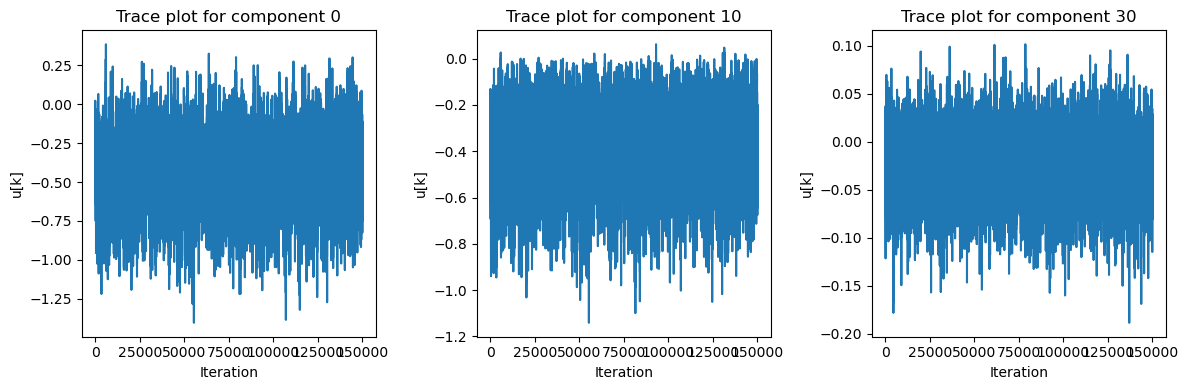

In [10]:
import matplotlib.pyplot as plt

idxs = [0, 10, 30]   # example components to inspect

plt.figure(figsize=(12,4))
for i, k in enumerate(idxs):
    plt.subplot(1,3,i+1)
    plt.plot(chain[:,k])
    plt.title(f"Trace plot for component {k}")
    plt.xlabel("Iteration")
    plt.ylabel("u[k]")
plt.tight_layout()
plt.show()
